In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

sns.set()

# Métodos de ensamble
## Boosting y XGBoost
**Aprendizaje de Máquina - CEIA - FIUBA**

En la notebook anterior vimos **bagging** y **random forest**: entrenar muchos árboles
**en paralelo**, cada uno sobre datos remuestreados, y promediarlos. La clave era
reducir la **varianza** de un modelo que individualmente era muy inestable.

El **boosting** ataca el problema desde el lado opuesto. En lugar de entrenar muchos
modelos fuertes en paralelo y promediarlos, entrena muchos modelos **débiles en
secuencia**, donde cada uno se dedica a **corregir los errores del anterior**. La
predicción final es la suma de todos.

| | Bagging / Random Forest | Boosting |
|---|---|---|
| Cómo se entrenan | En paralelo, independientes | En secuencia, cada uno depende del anterior |
| Modelo base | Fuerte (árbol profundo) | Débil (árbol muy poco profundo) |
| Qué reduce | **Varianza** | **Sesgo** (y algo de varianza) |
| Datos de cada modelo | Remuestreo bootstrap | Los mismos, repesados o los residuos |
| ¿Más modelos sobreajusta? | **No**, satura | **Sí**, hay que controlarlo |
| Paralelizable | Sí | No (es secuencial) |

Esa ante última fila importa: como el boosting **sí puede sobreajustar** si lo dejamos correr
de más, vamos a necesitar mecanismos de control (learning rate, early stopping,
regularización) que en bagging no hacían falta.

Seguimos con **Hitters**, el mismo preprocesamiento y el mismo split de la notebook anterior.

In [2]:
df_hitters = pd.read_csv("datasets/Hitters.csv").dropna(subset="Salary")
df_hitters["Salary_log"] = np.log(df_hitters["Salary"])

df_hitters_dummies = pd.get_dummies(data=df_hitters,
                                    columns=['League', 'Division', 'NewLeague'],
                                    drop_first=True)

X_cols = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
          'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
          'Errors', 'League_N', 'Division_W', 'NewLeague_N']

X = df_hitters_dummies.loc[:, X_cols]
y = df_hitters_dummies.loc[:, 'Salary_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras | Testeo: {X_test.shape[0]}")

Entrenamiento: 184 muestras | Testeo: 79


In [3]:
def evaluar(nombre, modelo, cv=True):
    """Entrena, evalúa en test y (opcionalmente) estima el MAE por CV."""
    mae_cv = np.nan
    if cv:
        mae_cv = -cross_val_score(modelo, X_train, y_train, cv=5,
                                  scoring='neg_mean_absolute_error',
                                  n_jobs=-1).mean()

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nombre,
        "MAE (train)": mean_absolute_error(y_train, modelo.predict(X_train)),
        "MAE (CV)": mae_cv,
        "MAE (test)": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }

---
## La intuición: aprender de los residuos

Antes de usar ninguna librería, construyamos un boosting **a mano**. Es más simple de lo
que parece.

La receta del *gradient boosting* para regresión es:

1. Empezamos con una predicción trivial: el **promedio** de $y$.
2. Calculamos los **residuos**: $r = y - \hat{y}$, o sea, lo que todavía nos falta
   explicar.
3. Entrenamos un árbol muy chico (un *tocón* o *stump*, de profundidad 1) para predecir
   **esos residuos**.
4. Sumamos una fracción $\eta$ (el *learning rate*) de esa corrección a nuestra
   predicción.
5. Volvemos al paso 2.

Cada árbol no predice el salario: predice **el error que todavía tenemos**. Para poder
graficarlo, hagámoslo usando un solo atributo (`CHits`).

In [4]:
X_uni = X_train[["CHits"]]
grilla = pd.DataFrame(
    np.linspace(X["CHits"].min(), X["CHits"].max(), 400), columns=["CHits"]) # type: ignore

eta = 0.3               # learning rate
n_iter = 60             # cantidad de árboles

# Paso 1: la predicción inicial es simplemente el promedio
pred = np.full(len(y_train), y_train.mean())
pred_grilla = np.full(len(grilla), y_train.mean())

historia = {}
for it in range(1, n_iter + 1):
    # Paso 2: ¿qué nos falta explicar?
    residuos = y_train.values - pred

    # Paso 3: un árbol chiquito que aprende los residuos
    tocon = DecisionTreeRegressor(max_depth=1).fit(X_uni, residuos)

    # Guardamos el estado ANTES de aplicar la corrección, para graficar
    if it in (1, 2, 10, 60):
        historia[it] = {
            "pred_grilla": pred_grilla.copy(),
            "residuos": residuos.copy(),
            "correccion": tocon.predict(grilla),
        }

    # Paso 4: sumamos una fracción de la corrección
    pred = pred + eta * tocon.predict(X_uni)
    pred_grilla = pred_grilla + eta * tocon.predict(grilla)

print(f"MAE en entrenamiento tras {n_iter} iteraciones: "
      f"{mean_absolute_error(y_train, pred):.4f}")

MAE en entrenamiento tras 60 iteraciones: 0.2838


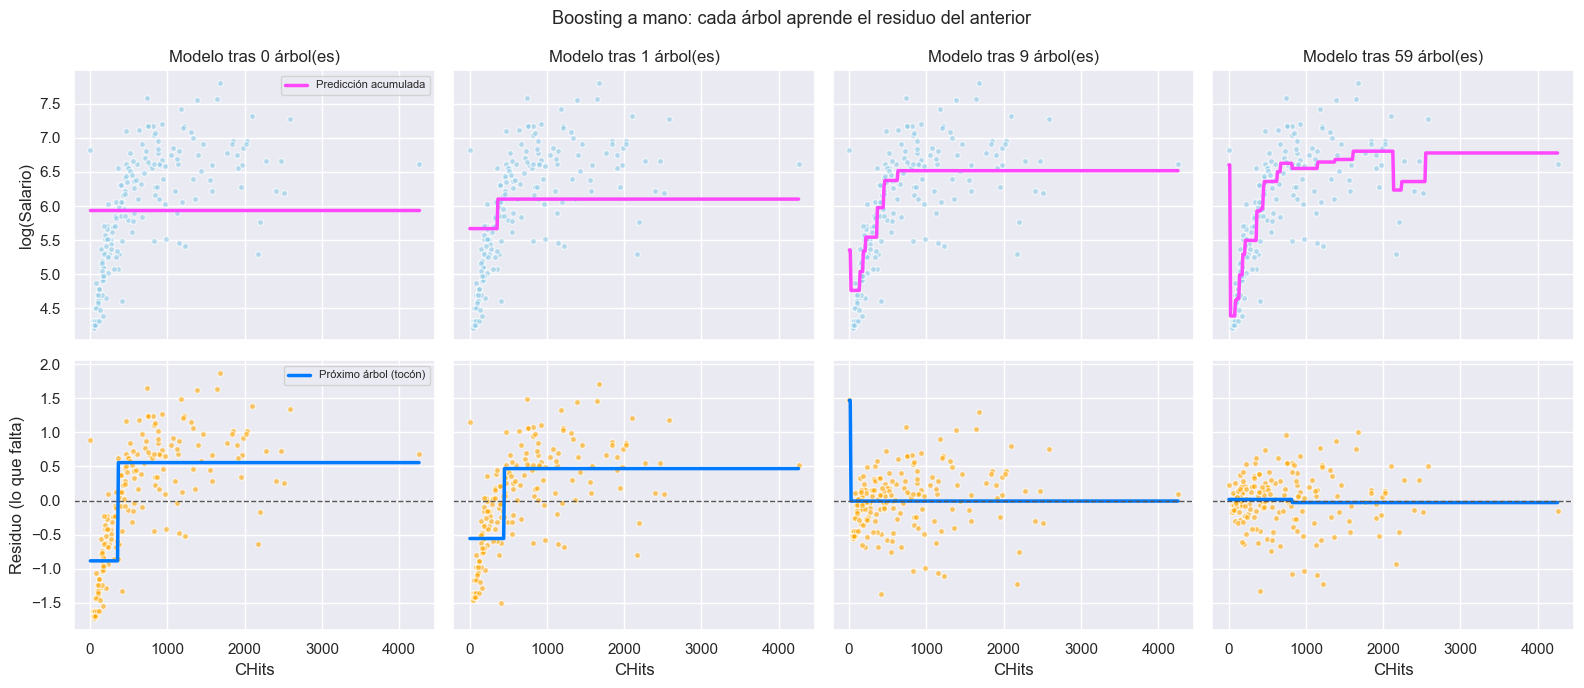

In [5]:
# sharey="row" para que se vea cómo se achican los residuos entre paneles
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey="row")

for col, it in enumerate([1, 2, 10, 60]):
    h = historia[it]

    # Fila de arriba: el modelo acumulado hasta esa iteración
    axes[0, col].scatter(X_train["CHits"], y_train, s=18, color="#8ecae6",
                         alpha=0.6, edgecolor="white")
    axes[0, col].plot(grilla["CHits"], h["pred_grilla"], color="#ff48fd", lw=2.5)
    axes[0, col].set_title(f"Modelo tras {it - 1} árbol(es)")
    if col == 0:
        axes[0, col].set_ylabel("log(Salario)")

    # Fila de abajo: los residuos que quedan y el tocón que los ataca
    axes[1, col].scatter(X_train["CHits"], h["residuos"], s=18, color="#ffa600",
                         alpha=0.6, edgecolor="white")
    axes[1, col].plot(grilla["CHits"], h["correccion"], color="#007aff", lw=2.5)
    axes[1, col].axhline(0, color="#555555", lw=1, linestyle="--")
    axes[1, col].set_xlabel("CHits")
    if col == 0:
        axes[1, col].set_ylabel("Residuo (lo que falta)")

axes[0, 0].plot([], [], color="#ff48fd", lw=2.5, label="Predicción acumulada")
axes[0, 0].legend(fontsize=8)
axes[1, 0].plot([], [], color="#007aff", lw=2.5, label="Próximo árbol (tocón)")
axes[1, 0].legend(fontsize=8)

plt.suptitle("Boosting a mano: cada árbol aprende el residuo del anterior",
             fontsize=13)
plt.tight_layout()
plt.show()

Se ve el mecanismo completo:

- **Iteración 1** (izquierda): el modelo es una recta horizontal (el promedio) y los
  residuos son enormes y con estructura clarísima. El tocón azul parte esa estructura
  por la mitad.
- **Iteraciones siguientes**: el modelo acumulado (rosa) se va volviendo escalonado y
  cada vez más ajustado, mientras los residuos naranjas se van **achatando hacia cero**
  y perdiendo estructura.
- **Iteración 60**: los residuos ya no tienen una forma evidente que un tocón pueda
  aprovechar. El modelo capturó la señal que había en `CHits`.

Notemos la diferencia conceptual con bagging: acá **ningún árbol individual intenta
predecir el salario**. Cada uno predice sólo la porción de error que dejó el anterior, y
recién la **suma** de todos produce el modelo.

El `learning_rate` ($\eta$) controla cuánto de cada corrección aplicamos. Con $\eta$
chico avanzamos despacio y necesitamos más árboles, pero generalizamos mejor: es el
equivalente a no creerle demasiado a ningún árbol individual.

---
## AdaBoost

[`AdaBoost`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html)
(*Adaptive Boosting*) es el boosting histórico, anterior a la formulación con
gradientes. En lugar de ajustar residuos, **repesa las muestras**: las que el ensamble
viene prediciendo mal reciben más peso, de modo que el siguiente modelo se concentre en
ellas.

Acá vale la pena hacer un experimento que enseña más que el resultado en sí. Comparemos
dos AdaBoost: uno con hiper-parámetros elegidos sin criterio y otro razonable.

In [6]:
# Configuración descuidada: learning rate diminuto, aprendices mínimos (tocones)
# y pocos árboles. Cada corrección es minúscula y son muy pocas.
ada_malo = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1),
                             n_estimators=50, learning_rate=0.01,
                             random_state=42)

# Configuración razonable: árboles con algo más de capacidad, un learning rate
# que permita avanzar y suficientes iteraciones
ada_bueno = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                              n_estimators=300, learning_rate=0.5,
                              random_state=42)

# Como referencia, el error de predecir siempre el promedio
mae_trivial = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f"MAE de predecir siempre el promedio: {mae_trivial:.4f}\n")

metricas = [
    evaluar("AdaBoost (mal configurado)", ada_malo),
    evaluar("AdaBoost (bien configurado)", ada_bueno),
]
pd.DataFrame(metricas).set_index("modelo").round(4)

MAE de predecir siempre el promedio: 0.7363



,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
AdaBoost (mal configurado),0.4281,0.4575,0.4888,0.6745,0.0848,0.4164
AdaBoost (bien configurado),0.1545,0.2957,0.3132,0.4748,0.0545,0.7107


La diferencia es enorme: el **mismo algoritmo** pasa de un MAE de testeo de ≈ 0.49
—peor incluso que el árbol podado de la clase 4, que daba 0.46— a ≈ 0.31, el mejor
resultado que conseguimos hasta ahora en este dataset.

Vale la pena entender *por qué* falla la primera configuración. Su MAE de
**entrenamiento** es ≈ 0.43, mientras que predecir siempre el promedio da ≈ 0.74: el
modelo se movió, pero se quedó muy lejos de ajustar los datos. Con $\eta = 0.01$ cada
árbol aporta apenas un 1% de su corrección, y con sólo 50 árboles la suma total de
correcciones es minúscula. **El modelo no sobreajusta: no llega ni a ajustar.**

De acá salen dos lecciones:

1. **`n_estimators` y `learning_rate` están acoplados.** Bajar el learning rate exige
   subir la cantidad de árboles para compensar. Si se toca uno solo, el modelo queda a
   mitad de camino.
2. **Cuando un algoritmo da mal, hay que verificar la configuración antes de concluir
   que "no sirve".** Es muy fácil descartar un método por un mal tuning y quedarse con
   una conclusión falsa —y en boosting, con tres hiper-parámetros acoplados, es
   especialmente fácil.

---
## Gradient Boosting

[`GradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
es la implementación de Scikit-Learn de lo que hicimos a mano más arriba: cada árbol
ajusta el gradiente negativo de la función de pérdida (para el error cuadrático, eso es
exactamente el residuo).

Su mayor virtud didáctica es `staged_predict()`, que nos deja ver la predicción del
ensamble **después de cada árbol**. Con eso podemos observar el sobreajuste apareciendo
en vivo.

In [7]:
gb = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.1,
                               max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# Error de train y test después de CADA árbol
mae_train_it = np.array([mean_absolute_error(y_train, p)
                         for p in gb.staged_predict(X_train)])
mae_test_it = np.array([mean_absolute_error(y_test, p)
                        for p in gb.staged_predict(X_test)])

mejor_it = int(mae_test_it.argmin()) + 1
print(f"Mínimo MAE de testeo: {mae_test_it.min():.4f} "
      f"en la iteración {mejor_it} (de {len(mae_test_it)})")
print(f"MAE de testeo al final (1000 árboles): {mae_test_it[-1]:.4f}")

Mínimo MAE de testeo: 0.3379 en la iteración 24 (de 1000)
MAE de testeo al final (1000 árboles): 0.3506


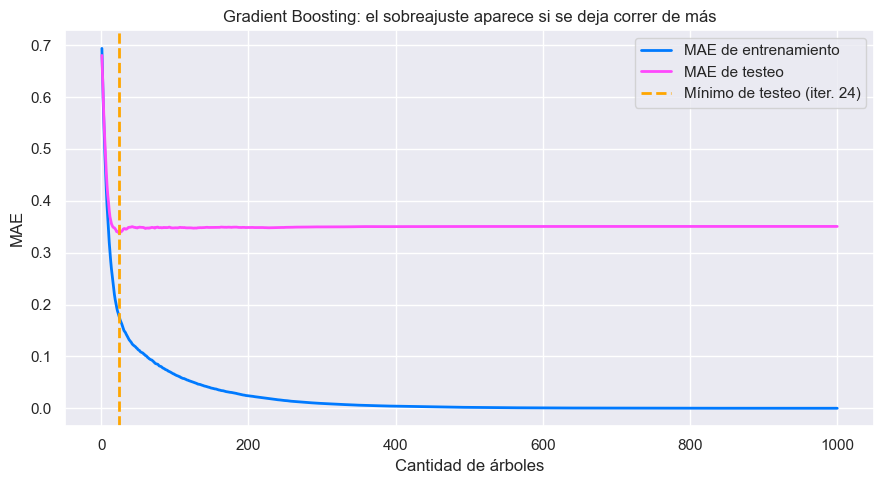

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(mae_train_it) + 1), mae_train_it, color="#007aff", lw=2,
        label="MAE de entrenamiento")
ax.plot(range(1, len(mae_test_it) + 1), mae_test_it, color="#ff48fd", lw=2,
        label="MAE de testeo")
ax.axvline(mejor_it, color="#ffa600", linestyle="--", lw=2,
           label=f"Mínimo de testeo (iter. {mejor_it})")
ax.set_xlabel("Cantidad de árboles")
ax.set_ylabel("MAE")
ax.set_title("Gradient Boosting: el sobreajuste aparece si se deja correr de más")
ax.legend()
plt.tight_layout()
plt.show()

Acá está **la diferencia fundamental con bagging**. En la notebook anterior, la
curva de error contra cantidad de árboles bajaba y se **estabilizaba**: agregar árboles
nunca empeoraba nada. Acá no: el error de entrenamiento sigue bajando hacia cero (el
ensamble memoriza), pero el de testeo **toca un mínimo y después empieza a subir**.

Por eso en boosting `n_estimators` **no** es "cuanto más, mejor": es un
hiper-parámetro que hay que ajustar, y la forma estándar de hacerlo es el **early
stopping**, que veremos con XGBoost.

Veamos ahora cómo interactúa el `learning_rate` con la cantidad de árboles.

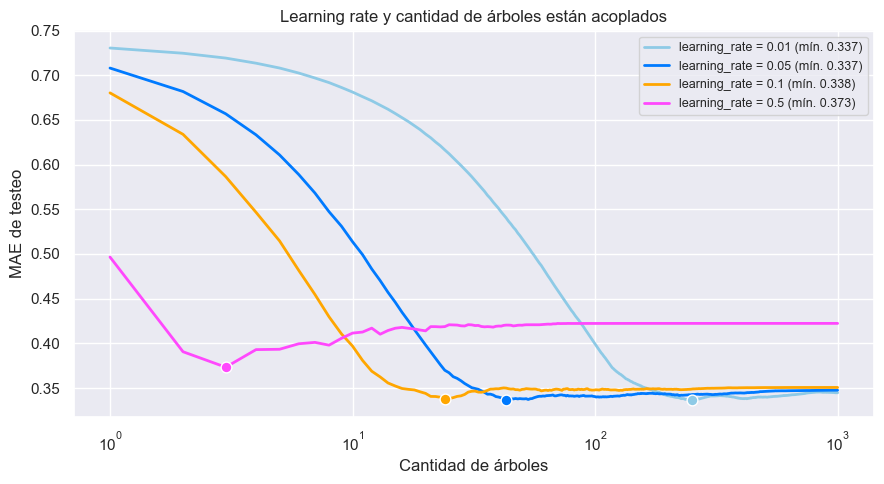

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colores_lr = {0.01: "#8ecae6", 0.05: "#007aff", 0.1: "#ffa600", 0.5: "#ff48fd"}

for lr, color in colores_lr.items():
    modelo = GradientBoostingRegressor(n_estimators=1000, learning_rate=lr,
                                       max_depth=3, random_state=42)
    modelo.fit(X_train, y_train)
    curva = np.array([mean_absolute_error(y_test, p)
                      for p in modelo.staged_predict(X_test)])
    ax.plot(range(1, 1001), curva, color=color, lw=2,
            label=f"learning_rate = {lr} (mín. {curva.min():.3f})")
    ax.scatter([curva.argmin() + 1], [curva.min()], color=color, s=60, zorder=3,
               edgecolor="white")

ax.set_xlabel("Cantidad de árboles")
ax.set_ylabel("MAE de testeo")
ax.set_xscale("log")
ax.set_title("Learning rate y cantidad de árboles están acoplados")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

El gráfico (con el eje x en escala logarítmica) muestra el compromiso:

- Con `learning_rate = 0.5` el modelo llega rápido a su mejor punto y enseguida empieza
  a sobreajustar.
- Con `learning_rate = 0.01` avanza muy despacio: necesita muchísimos árboles, pero la
  curva es más plana y estable cerca del mínimo.
- Los valores intermedios suelen dar el mejor equilibrio.

La regla práctica es: **bajar el learning rate y compensar con más árboles** suele
mejorar la generalización, hasta que el costo de cómputo deja de justificarlo.

---
## XGBoost

[XGBoost](https://xgboost.readthedocs.io/en/stable/) es una implementación de gradient
boosting que agrega, entre otras cosas:

- **Regularización explícita** (`reg_lambda` para L2 y `reg_alpha` para L1) sobre los
  valores de las hojas, algo que el gradient boosting clásico no tiene.
- **Submuestreo** de filas (`subsample`) y de columnas (`colsample_bytree`), tomando
  prestada la idea de bagging y random forest.
- Una implementación mucho más rápida y paralelizada, con soporte de **early stopping**.

Hay que instalarla aparte:

```bash
pip install xgboost
# o bien:  conda install conda-forge::xgboost
# o bien:  poetry add xgboost
# o bien:  uv add xgboost
```

Empecemos por los valores por defecto.

In [10]:
xgb_default = xgb.XGBRegressor(random_state=42, n_jobs=-1)

metricas.append(evaluar("XGBoost (por defecto)", xgb_default))
pd.DataFrame(metricas).set_index("modelo").round(4)

,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
AdaBoost (mal configurado),0.4281,0.4575,0.4888,0.6745,0.0848,0.4164
AdaBoost (bien configurado),0.1545,0.2957,0.3132,0.4748,0.0545,0.7107
XGBoost (por defecto),0.0005,0.3319,0.3770,0.5490,0.0659,0.6133


Mirá la columna **MAE (train)**: prácticamente **cero**. XGBoost por defecto usa
`n_estimators=100` con `learning_rate=0.3` y `max_depth=6`, que para un dataset de 184
filas es muchísimo: memoriza el entrenamiento. Es justo el sobreajuste que anticipaba la
curva del gradient boosting.

### Early stopping

La solución estándar es dejar de agregar árboles cuando el error en un conjunto de
validación deja de mejorar. Para eso separamos una parte del entrenamiento como
validación.

> Importante: la validación sale del **entrenamiento**, nunca del testeo. Si usáramos el
> testeo para decidir cuándo parar, estaríamos otra vez tomando una decisión de modelado
> mirando datos que deberían quedar intactos.

In [11]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25,
                                            random_state=42)

xgb_es = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=3,
                          early_stopping_rounds=50, eval_metric="mae",
                          random_state=42, n_jobs=-1)
xgb_es.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print(f"Árboles usados: {xgb_es.best_iteration + 1} de 2000")
print(f"MAE de testeo: {mean_absolute_error(y_test, xgb_es.predict(X_test)):.4f}")

Árboles usados: 104 de 2000
MAE de testeo: 0.3586


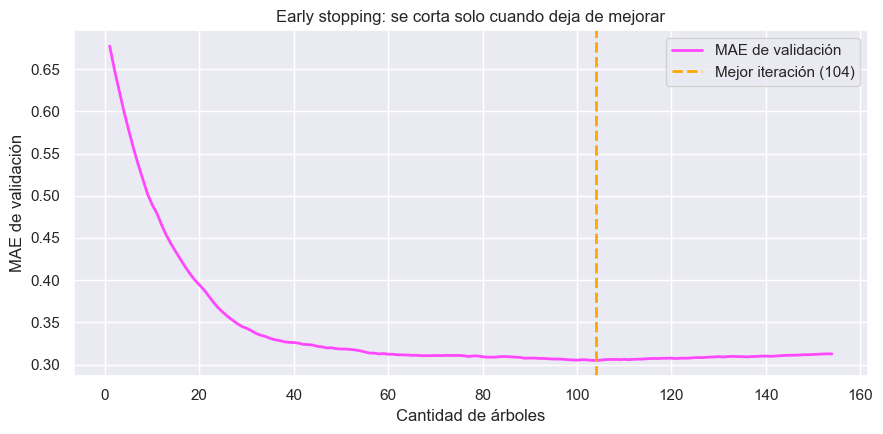

In [12]:
historial = xgb_es.evals_result()['validation_0']['mae']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, len(historial) + 1), historial, color="#ff48fd", lw=2,
        label="MAE de validación")
ax.axvline(xgb_es.best_iteration + 1, color="#ffa600", linestyle="--", lw=2,
           label=f"Mejor iteración ({xgb_es.best_iteration + 1})")
ax.set_xlabel("Cantidad de árboles")
ax.set_ylabel("MAE de validación")
ax.set_title("Early stopping: se corta solo cuando deja de mejorar")
ax.legend()
plt.tight_layout()
plt.show()

### Búsqueda de hiper-parámetros con Optuna

XGBoost tiene muchos hiper-parámetros y están fuertemente acoplados entre sí, así que la
búsqueda manual no es opción. Usamos [Optuna](https://optuna.org/), igual que en las
clases 2 y 4, optimizando el **MAE por validación cruzada sobre el entrenamiento**.

In [13]:
import optuna


def objective(trial):
    modelo = xgb.XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 20, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        random_state=42, n_jobs=1,
    )
    score = cross_val_score(modelo, X_train, y_train, cv=5,
                            scoring='neg_mean_absolute_error', n_jobs=-1)
    return -score.mean()


def champion_callback(study, frozen_trial):
    """Mostramos menos información, sino es demasiado verboso"""
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) /
                                   study.best_value) * 100
            print(f"Trial {frozen_trial.number} achieved value: "
                  f"{frozen_trial.value:.5f} with "
                  f"{improvement_percent: .4f}% improvement")
        else:
            print(f"Initial trial {frozen_trial.number} achieved "
                  f"value: {frozen_trial.value:.5f}")

In [14]:
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

best_params = study.best_params
print(f"\nMejor MAE de CV: {study.best_value:.4f}")
best_params

Initial trial 0 achieved value: 0.30569
Trial 2 achieved value: 0.29471 with  3.7265% improvement
Trial 3 achieved value: 0.28835 with  2.2045% improvement
Trial 8 achieved value: 0.28472 with  1.2756% improvement
Trial 21 achieved value: 0.28148 with  1.1488% improvement
Trial 31 achieved value: 0.27869 with  1.0032% improvement
Trial 40 achieved value: 0.27726 with  0.5145% improvement
Trial 41 achieved value: 0.27572 with  0.5594% improvement
Trial 80 achieved value: 0.27540 with  0.1171% improvement
Trial 182 achieved value: 0.27535 with  0.0167% improvement
Trial 223 achieved value: 0.27476 with  0.2162% improvement
Trial 247 achieved value: 0.27474 with  0.0044% improvement
Trial 257 achieved value: 0.27430 with  0.1619% improvement

Mejor MAE de CV: 0.2743


{'n_estimators': 600,
 'learning_rate': 0.012597355410411105,
 'max_depth': 8,
 'subsample': 0.562006207081216,
 'colsample_bytree': 0.7291611746452787,
 'min_child_weight': 12,
 'reg_lambda': 0.06152517716630232,
 'reg_alpha': 0.05502003682572415}

In [15]:
xgb_opt = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)

metricas.append(evaluar("XGBoost (Optuna)", xgb_opt))
pd.DataFrame(metricas).set_index("modelo").round(4)

,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
AdaBoost (mal configurado),0.4281,0.4575,0.4888,0.6745,0.0848,0.4164
AdaBoost (bien configurado),0.1545,0.2957,0.3132,0.4748,0.0545,0.7107
XGBoost (por defecto),0.0005,0.3319,0.3770,0.5490,0.0659,0.6133
XGBoost (Optuna),0.1327,0.2743,0.3472,0.5732,0.0598,0.5784


### Importancia de atributos en XGBoost

XGBoost ofrece **tres** definiciones distintas de importancia, y conviene saber qué mide
cada una porque dan rankings diferentes:

- **`weight`**: cuántas veces se usó el atributo para dividir. Favorece a las variables
  continuas, que se usan muchas veces en cortes finos.
- **`gain`**: cuánta mejora promedio aportaron esas divisiones. **Es la más informativa**
  y la que conviene mirar por defecto.
- **`cover`**: cuántas muestras pasaron por las divisiones que usan ese atributo.

Agregamos además la **importancia por permutación** sobre el testeo, como en la notebook
anterior.

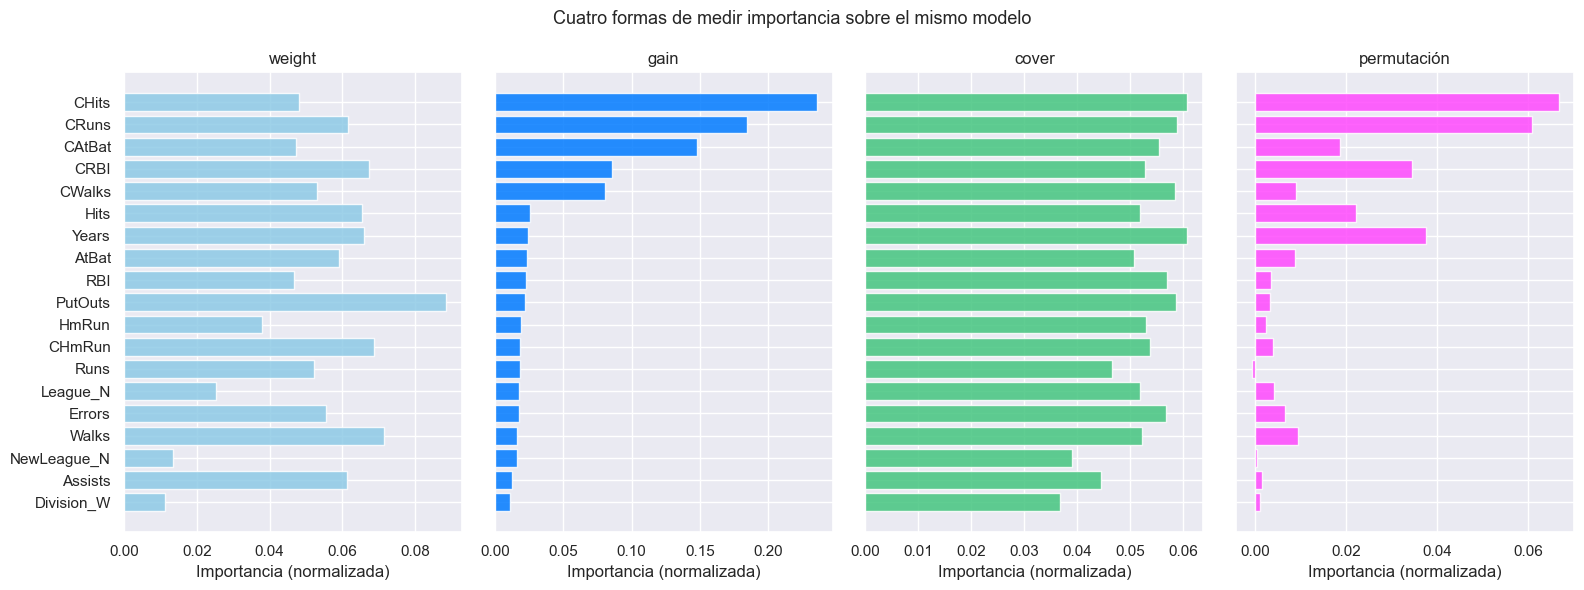

In [16]:
xgb_opt.fit(X_train, y_train)
booster = xgb_opt.get_booster()

importancias = pd.DataFrame({
    tipo: pd.Series(booster.get_score(importance_type=tipo))
    for tipo in ["weight", "gain", "cover"]
}).reindex(X_cols).fillna(0)

# Normalizamos cada columna para poder compararlas en la misma escala
importancias = importancias / importancias.sum()

perm = permutation_importance(xgb_opt, X_test, y_test, n_repeats=30,
                              random_state=42, n_jobs=-1,
                              scoring='neg_mean_absolute_error')
importancias["permutación"] = perm.importances_mean

orden = importancias["gain"].sort_values().index

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
colores_imp = ["#8ecae6", "#007aff", "#44c57f", "#ff48fd"]
for ax, tipo, color in zip(axes, importancias.columns, colores_imp):
    ax.barh(orden, importancias.loc[orden, tipo], color=color, alpha=0.85)
    ax.set_title(tipo)
    ax.set_xlabel("Importancia (normalizada)")

plt.suptitle("Cuatro formas de medir importancia sobre el mismo modelo", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
importancias.assign(
    rank_gain=importancias["gain"].rank(ascending=False).astype(int),
    rank_perm=importancias["permutación"].rank(ascending=False).astype(int),
).sort_values("gain", ascending=False).round(4)

,weight,gain,cover,permutación,rank_gain,rank_perm
CHits,0.0480,0.2352,0.0608,0.0667,1,1
CRuns,0.0615,0.1848,0.0589,0.0609,2,2
CAtBat,0.0474,0.1475,0.0555,0.0187,3,6
CRBI,0.0672,0.0854,0.0529,0.0345,4,4
CWalks,0.0531,0.0808,0.0584,0.0090,5,8
Hits,0.0655,0.0257,0.0519,0.0221,6,5
Years,0.0661,0.0240,0.0608,0.0375,7,3
AtBat,0.0592,0.0234,0.0507,0.0089,8,9
RBI,0.0468,0.0226,0.0569,0.0035,9,13
PutOuts,0.0885,0.0222,0.0587,0.0032,10,14


Los cuatro paneles cuentan historias parecidas pero no idénticas, y esa es la
moraleja: **"importancia de atributos" no es una cantidad única y bien definida**.
Depende de qué se mide. Reportar un ranking sin aclarar con qué criterio se calculó es
una fuente habitual de conclusiones erróneas.

Como en la notebook anterior, las variables de **carrera** y los **años de experiencia**
dominan, lo cual es consistente con el EDA y con el baseline por tramos de
años.

---
## Comparativa final sobre Hitters

Juntamos **todos** los modelos del curso sobre este dataset, con el mismo split
(`test_size=0.3`, `random_state=42`), incluyendo la heurística de referencia:

- **Baseline (tramos de años)** — heurística del EDA: el salario promedio
  del tramo de experiencia del jugador, sin entrenamiento.
- **Regresión Lineal (OLS)** y **Ridge** (`alpha=13.67`).
- **SVR (RBF)** (`C=10`, `gamma=0.1`) — ultimo campeón.
- **Árbol de regresión podado** (`ccp_alpha=0.005`).
- **Bagging** y **Random Forest** — notebook 2.
- **AdaBoost**, **Gradient Boosting** y **XGBoost** — esta notebook.

In [18]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# --- Baseline heurístico: promedio de log(Salary) por tramo de años ---
bins = [0, 2, 4, 6, 9, 13, np.inf]
tramo_train = pd.cut(X_train["Years"], bins=bins)
tramo_test = pd.cut(X_test["Years"], bins=bins)
prom_por_tramo = y_train.groupby(tramo_train, observed=False).mean()
y_pred_base = tramo_test.map(prom_por_tramo).astype(float).values

fila_baseline = {
    "modelo": "Baseline (tramos de años)",
    "MAE (train)": mean_absolute_error(
        y_train, tramo_train.map(prom_por_tramo).astype(float).values),
    "MAE (CV)": np.nan,
    "MAE (test)": mean_absolute_error(y_test, y_pred_base),
    "RMSE": root_mean_squared_error(y_test, y_pred_base),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_base),
    "R2": r2_score(y_test, y_pred_base),
}

df_final = pd.DataFrame([
    fila_baseline,
    evaluar("Regresión Lineal",
            Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])),
    evaluar("Ridge",
            Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=13.67))])),
    evaluar("SVR RBF",
            Pipeline([('sc', StandardScaler()),
                      ('m', SVR(C=10, gamma=0.1, kernel='rbf'))])),
    evaluar("Árbol podado",
            DecisionTreeRegressor(random_state=42, ccp_alpha=0.005)),
    evaluar("Bagging",
            BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                             n_estimators=200, random_state=42, n_jobs=-1)),
    evaluar("Random Forest",
            RandomForestRegressor(n_estimators=500, max_features=0.35,
                                  random_state=42, n_jobs=-1)),
    evaluar("AdaBoost", ada_bueno),
    evaluar("Gradient Boosting",
            GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=3, random_state=42)),
    evaluar("XGBoost", xgb_opt),
]).set_index("modelo")

df_final.round(4)

,MAE (train),MAE (CV),MAE (test),RMSE,MAPE,R2
modelo,,,,,,
Baseline (tramos de años),0.4729,NaN,0.5068,0.7027,0.0869,0.3665
Regresión Lineal,0.4744,0.5380,0.5154,0.6779,0.0907,0.4103
Ridge,0.4839,0.5206,0.5118,0.6626,0.0904,0.4366
SVR RBF,0.0878,0.3771,0.3918,0.5702,0.0683,0.5828
Árbol podado,0.2211,0.3643,0.4644,0.6653,0.0796,0.4321
Bagging,0.1051,0.2839,0.3487,0.5349,0.0604,0.6329
Random Forest,0.1024,0.2735,0.3387,0.5203,0.0585,0.6527
AdaBoost,0.1545,0.2957,0.3132,0.4748,0.0545,0.7107
Gradient Boosting,0.0661,0.2986,0.3431,0.5034,0.0598,0.6748


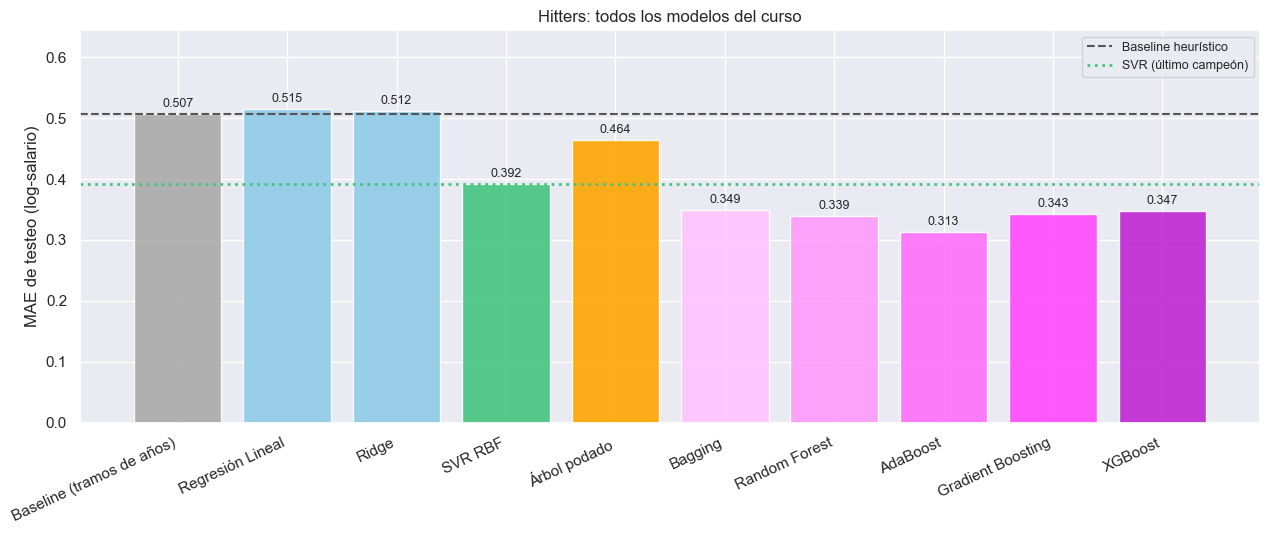

In [19]:
orden_m = ["Baseline (tramos de años)", "Regresión Lineal", "Ridge",
           "SVR RBF", "Árbol podado", "Bagging",
           "Random Forest", "AdaBoost", "Gradient Boosting",
           "XGBoost"]
colores_m = ["#aaaaaa", "#8ecae6", "#8ecae6", "#44c57f", "#ffa600",
             "#ffc4fe", "#ff9bfd", "#ff6ffd", "#ff48fd", "#c026d3"]

fig, ax = plt.subplots(figsize=(13, 5.5))
barras = ax.bar(orden_m, df_final.loc[orden_m, "MAE (test)"], color=colores_m,
                alpha=0.9, edgecolor="white")
ax.bar_label(barras, fmt="%.3f", padding=3, fontsize=9)
ax.axhline(df_final.loc["Baseline (tramos de años)", "MAE (test)"],
           color="#555555", linestyle="--", lw=1.5, label="Baseline heurístico")
ax.axhline(df_final.loc["SVR RBF", "MAE (test)"], color="#44c57f",
           linestyle=":", lw=2, label="SVR (último campeón)")
ax.set_ylabel("MAE de testeo (log-salario)")
ax.set_ylim(0, df_final["MAE (test)"].max() * 1.25)
ax.set_title("Hitters: todos los modelos del curso")
plt.xticks(rotation=25, ha="right")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Observaciones

- **Todos los ensambles superan claramente al SVR**, que había sido el campeón en este dataset (MAE ≈ 0.39). Con respecto al árbol podado (≈ 0.46) la mejora va del 25% al 33% según el ensamble.
- **Contra el baseline heurístico** (MAE ≈ 0.51), los ensambles quedan entre un 31% y un
  38% mejor. Vale la pena tenerlo presente: los modelos lineales apenas le sacaban
  ventaja a esa única regla, y recién los ensambles justifican de verdad la complejidad
  adicional.
- **Boosting y bagging quedan parejos entre sí**, con diferencias de 0.01–0.03 en MAE.
  No hay un ganador claro entre las dos familias en este dataset.

**Y acá conviene detenerse en algo incómodo.** Comparemos los dos rankings de la tabla:

| Puesto | Por **MAE (CV)** (184 muestras) | Por **MAE (test)** (79 muestras) |
|---|---|---|
| 1º | Random Forest (0.2735) | AdaBoost (0.3132) |
| 2º | XGBoost (0.2743) | Random Forest (0.3387) |
| 3º | Bagging (0.2839) | Gradient Boosting (0.3431) |
| 4º | AdaBoost (0.2957) | XGBoost (0.3472) |
| 5º | Gradient Boosting (0.2986) | Bagging (0.3487) |

**El orden se invierte casi por completo.** El que gana por validación cruzada queda
segundo en test, y el que gana en test es cuarto por CV. Con 79 muestras de testeo, la
diferencia entre el primero y el último es de unas pocas predicciones.

La conclusión no es que las métricas "fallen", sino que en un dataset de este tamaño
**las diferencias entre ensambles bien configurados no son estadísticamente
distinguibles**. Cualquiera de los cinco es una elección defendible, y elegir "el mejor"
mirando la tercera cifra decimal del test es autoengaño. Lo que sí es sólido y se repite
en ambas columnas es la diferencia **entre familias**: ensambles ≫ árbol podado ≫
modelos lineales ≈ baseline.

- **AdaBoost bien configurado es plenamente competitivo**, lejos del papelón que hacía
  con los hiper-parámetros descuidados. El algoritmo estaba bien; la configuración no.

### El elefante en la habitación: XGBoost no arrasa

Vale la pena decirlo explícitamente, porque contradice la fama del método: **acá
XGBoost no le gana al Random Forest**, a pesar de tener ocho hiper-parámetros contra
prácticamente ninguno y de haberle dedicado 300 iteraciones de Optuna. Por CV quedan
empatados (0.2743 vs 0.2735, a favor del bosque) y por test el bosque queda mejor.

No es un error: es lo que cabe esperar con **184 muestras de entrenamiento**. XGBoost
tiene una enorme capacidad de ajuste, y esa capacidad sólo rinde cuando hay suficientes
datos para estimar bien todos sus parámetros. Con datasets chicos, un Random Forest —que
esencialmente no necesita tuning— es un rival durísimo y mucho más barato de poner a
punto.

La conclusión práctica es: **XGBoost no es la respuesta por defecto a todo**. Es la
respuesta cuando hay volumen de datos. Y eso es justamente lo que vamos a comprobar en
el apéndice.

---
## Apéndice: ¿dónde sí brilla XGBoost?

Para ver la otra cara, repitamos la comparación sobre un dataset **100 veces más
grande**: [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset),
con **20.640 observaciones** (contra las 263 de Hitters).

Derivado del censo de EE.UU. de 1990, cada observación es un bloque censal y se busca
predecir el valor medio de las viviendas (en cientos de miles de dólares) a partir de 8
atributos: ingreso medio del bloque, antigüedad de las casas, cantidad promedio de
habitaciones y dormitorios por hogar, población, ocupantes promedio por hogar, latitud y
longitud.

Usamos los mismos modelos, sin tuning fino, sólo para comparar familias.

In [20]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    california.data, california.target, test_size=0.2, random_state=42)

print(f"California Housing — entrenamiento: {Xc_train.shape[0]} muestras, "
      f"testeo: {Xc_test.shape[0]}")
print(f"Hitters             — entrenamiento: {X_train.shape[0]} muestras, "
      f"testeo: {X_test.shape[0]}")

California Housing — entrenamiento: 16512 muestras, testeo: 4128
Hitters             — entrenamiento: 184 muestras, testeo: 79


In [21]:
def evaluar_california(nombre, modelo):
    modelo.fit(Xc_train, yc_train)
    y_pred = modelo.predict(Xc_test)
    return {
        "modelo": nombre,
        "MAE (train)": mean_absolute_error(yc_train, modelo.predict(Xc_train)),
        "MAE (test)": mean_absolute_error(yc_test, y_pred),
        "RMSE": root_mean_squared_error(yc_test, y_pred),
        "R2": r2_score(yc_test, y_pred),
    }


df_cal = pd.DataFrame([
    evaluar_california("Regresión Lineal", LinearRegression()),
    evaluar_california("Árbol de regresión",
                       DecisionTreeRegressor(max_depth=13, min_samples_leaf=16,
                                             random_state=42)),
    evaluar_california("Random Forest",
                       RandomForestRegressor(n_estimators=200, random_state=42,
                                             n_jobs=-1)),
    evaluar_california("Gradient Boosting",
                       GradientBoostingRegressor(n_estimators=500,
                                                 learning_rate=0.1, max_depth=5,
                                                 random_state=42)),
    evaluar_california("XGBoost",
                       xgb.XGBRegressor(n_estimators=500, learning_rate=0.1,
                                        max_depth=6, subsample=0.8,
                                        colsample_bytree=0.8, random_state=42,
                                        n_jobs=-1)),
]).set_index("modelo")

df_cal.round(4)

,MAE (train),MAE (test),RMSE,R2
modelo,,,,
Regresión Lineal,0.5286,0.5332,0.7456,0.5758
Árbol de regresión,0.3284,0.4026,0.5959,0.7290
Random Forest,0.1211,0.3266,0.5039,0.8062
Gradient Boosting,0.1989,0.3003,0.4574,0.8403
XGBoost,0.1465,0.2886,0.4449,0.8489


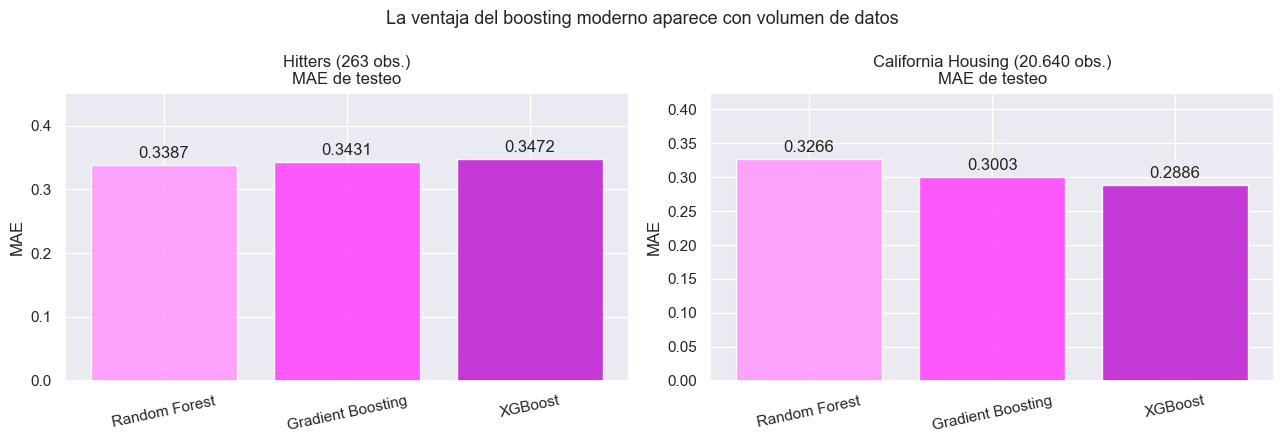

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: Hitters (263 observaciones)
comp_h = df_final.loc[["Random Forest", "Gradient Boosting",
                       "XGBoost"], "MAE (test)"]
comp_h.index = ["Random Forest", "Gradient Boosting", "XGBoost"]
b1 = axes[0].bar(comp_h.index, comp_h.values,
                 color=["#ff9bfd", "#ff48fd", "#c026d3"], alpha=0.9)
axes[0].bar_label(b1, fmt="%.4f", padding=3)
axes[0].set_title("Hitters (263 obs.)\nMAE de testeo")
axes[0].set_ylim(0, comp_h.max() * 1.3)

# Derecha: California Housing (20.640 observaciones)
comp_c = df_cal.loc[["Random Forest", "Gradient Boosting", "XGBoost"],
                    "MAE (test)"]
b2 = axes[1].bar(comp_c.index, comp_c.values,
                 color=["#ff9bfd", "#ff48fd", "#c026d3"], alpha=0.9)
axes[1].bar_label(b2, fmt="%.4f", padding=3)
axes[1].set_title("California Housing (20.640 obs.)\nMAE de testeo")
axes[1].set_ylim(0, comp_c.max() * 1.3)

for ax in axes:
    ax.set_ylabel("MAE")
    ax.tick_params(axis='x', rotation=12)

plt.suptitle("La ventaja del boosting moderno aparece con volumen de datos",
             fontsize=13)
plt.tight_layout()
plt.show()

### Observaciones del apéndice

Con 20.640 observaciones el panorama cambia: **XGBoost se despega del Random Forest de
forma clara**, mientras que en Hitters estaban empatados. La diferencia relativa es
mucho mayor que cualquiera de las que veíamos en el dataset chico, y además está medida
sobre 4.128 muestras de testeo, así que no es ruido.

La explicación es la misma que dimos antes, vista desde el otro lado: el boosting
construye el modelo corrigiendo errores de forma incremental, y con muchos árboles chicos
puede representar funciones muy detalladas. Eso requiere datos suficientes para que las
correcciones sean señal y no ruido. Con 184 filas no los hay; con 16.512, sí.

**La regla práctica que se lleva uno de estas dos notebooks:**

| Situación | Qué conviene |
|---|---|
| Pocos datos, poco tiempo de tuning | **Random Forest** — casi sin hiper-parámetros y muy difícil de arruinar |
| Muchos datos, se puede invertir en tuning | **XGBoost / boosting moderno** — el techo es más alto |
| Se necesita interpretabilidad máxima | **Un solo árbol podado**, asumiendo la pérdida de precisión |
| Modelos ya entrenados de familias distintas | **Voting / Stacking** (notebook 1) |

Y en todos los casos: **empezar por un baseline heurístico**, para saber cuánto está
aportando realmente el modelo.